<a href="https://colab.research.google.com/github/tejaswantt/ensembl-annotation-analysis-2/blob/main/genome_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:

!pip install pymysql

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 1.5 MB/s eta 0:00:00


In [3]:

import pymysql
import pandas as pd

conn = pymysql.connect(
    host='ensembldb.ensembl.org',
    user='anonymous',
    password=''
)

In [4]:

query = """
SELECT statistic, value
FROM homo_sapiens_core_110_38.genome_statistics
WHERE statistic IN ('transcript', 'noncoding_cnt', 'ref_length', 'total_length');
"""

df_human = pd.read_sql(query, conn)
df_human['species'] = 'human'
df_human

/tmp/ipykernel_13281/3357652988.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_human = pd.read_sql(query, conn)


,statistic,value,species
0,noncoding_cnt,25959,human
1,ref_length,3099750718,human
2,total_length,5221798225,human
3,transcript,252894,human


In [24]:

def get_species_data(db_name, species_name):
    query = f"""
    SELECT statistic, value
    FROM {db_name}.genome_statistics
    WHERE statistic IN ('transcript', 'noncoding_cnt', 'ref_length', 'total_length');
    """
    df = pd.read_sql(query, conn)
    df['species'] = species_name
    df['db_name'] = db_name   # 👈 ADD THIS
    df = df.pivot(index='species', columns='statistic', values='value')
    df['db_name'] = db_name   # keep after pivot
    return df.reset_index()

df_mouse = get_species_data('mus_musculus_core_110_39', 'mouse')
df_zebra = get_species_data('danio_rerio_core_110_11', 'zebrafish')


/tmp/ipykernel_13281/2172198866.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)
/tmp/ipykernel_13281/2172198866.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [6]:

def has_genome_stats(db_name):
    try:
        query = f"SHOW TABLES FROM {db_name} LIKE 'genome_statistics';"
        df = pd.read_sql(query, conn)
        return not df.empty
    except:
        return False

In [25]:

species_list = [

# -------- Mammals --------
('homo_sapiens_core_110_38', 'human'),
('mus_musculus_core_110_39', 'mouse'),
('rattus_norvegicus_core_110_72', 'rat'),
('bos_taurus_core_110_12', 'cow'),
('canis_lupus_familiaris_core_110_1', 'dog'),
('felis_catus_core_110_9', 'cat'),
('equus_caballus_core_110_3', 'horse'),
('sus_scrofa_core_110_111', 'pig'),
('gorilla_gorilla_core_110_4', 'gorilla'),
('pan_troglodytes_core_110_3', 'chimpanzee'),
('macaca_mulatta_core_110_10', 'macaque'),
('callithrix_jacchus_core_110_1', 'marmoset'),
('cercocebus_atys_core_110_1', 'sooty mangabey'),
('mandrillus_leucophaeus_core_110_1', 'mandrill'),
('papio_anubis_core_110_1', 'baboon'),
('chlorocebus_sabaeus_core_110_1', 'green monkey'),
('microcebus_murinus_core_110_3', 'mouse lemur'),
('otolemur_garnettii_core_110_3', 'bushbaby'),
('cavia_porcellus_core_110_4', 'guinea pig'),
('mesocricetus_auratus_core_110_10', 'hamster'),
('erinaceus_europaeus_core_110_1', 'hedgehog'),
('loxodonta_africana_core_110_3', 'elephant'),
('oryctolagus_cuniculus_core_110_2', 'rabbit'),
('capra_hircus_core_110_1', 'goat'),
('camelus_dromedarius_core_110_2', 'camel'),

# -------- Birds --------
('gallus_gallus_core_110_7', 'chicken'),
('meleagris_gallopavo_core_110_51', 'turkey'),
('anas_platyrhynchos_core_110_1', 'duck'),
('coturnix_japonica_core_110_2', 'quail'),
('falco_tinnunculus_core_110_1', 'kestrel'),
('cyanistes_caeruleus_core_110_2', 'blue tit'),
('parus_major_core_110_1', 'great tit'),
('zonotrichia_albicollis_core_110_101', 'white-throated sparrow'),
('taeniopygia_guttata_core_110_12', 'zebra finch'),
('pavo_cristatus_core_110_1', 'peacock'),
('struthio_camelus_australis_core_110_1', 'ostrich'),
('corvus_moneduloides_core_110_1', 'crow'),
('bubo_bubo_core_110_1', 'eagle owl'),
('athene_cunicularia_core_110_1', 'burrowing owl'),

# -------- Fish --------
('danio_rerio_core_110_11', 'zebrafish'),
('oryzias_latipes_core_110_1', 'medaka'),
('takifugu_rubripes_core_110_12', 'pufferfish'),
('gadus_morhua_core_110_3', 'cod'),
('clupea_harengus_core_110_202', 'herring'),
('latimeria_chalumnae_core_110_1', 'coelacanth'),
('poecilia_reticulata_core_110_1', 'guppy'),
('oreochromis_niloticus_core_110_3', 'tilapia'),
('fundulus_heteroclitus_core_110_302', 'killifish'),
('gasterosteus_aculeatus_core_110_1', 'stickleback'),
('larimichthys_crocea_core_110_20', 'croaker'),
('ictalurus_punctatus_core_110_12', 'catfish'),
('seriola_dumerili_core_110_1', 'amberjack'),
('sparus_aurata_core_110_11', 'sea bream'),
('cynoglossus_semilaevis_core_110_1', 'tongue sole'),
('parambassis_ranga_core_110_21', 'glass fish'),
('neogobius_melanostomus_core_110_2', 'goby'),
('echeneis_naucrates_core_110_11', 'remora'),
('cyclopterus_lumpus_core_110_1', 'lumpsucker'),
('scleropages_formosus_core_110_11', 'arowana'),

# -------- Reptiles --------
('anolis_carolinensis_core_110_2', 'green anole'),
('chelydra_serpentina_core_110_1', 'snapping turtle'),
('crocodylus_porosus_core_110_1', 'crocodile'),
('pogona_vitticeps_core_110_11', 'bearded dragon'),
('varanus_komodoensis_core_110_1', 'komodo dragon'),
('laticauda_laticaudata_core_110_1', 'sea snake'),
('naja_naja_core_110_5', 'cobra'),
('notechis_scutatus_core_110_2', 'tiger snake'),
('podarcis_muralis_core_110_1', 'wall lizard'),
('pelodiscus_sinensis_core_110_1', 'softshell turtle'),

# -------- Amphibians --------
('xenopus_tropicalis_core_110_10', 'frog'),
('leptobrachium_leishanense_core_110_1', 'toad'),
('chrysemys_picta_bellii_core_110_303', 'painted turtle'),

# -------- Invertebrates --------
('drosophila_melanogaster_core_110_10', 'fruit fly'),
('caenorhabditis_elegans_core_110_282', 'worm'),
('ciona_intestinalis_core_110_3', 'sea squirt'),
('ciona_savignyi_core_110_2', 'sea squirt 2'),
('saccharomyces_cerevisiae_core_110_4', 'yeast'),

# -------- Others --------
('ornithorhynchus_anatinus_core_110_1', 'platypus'),
('monodelphis_domestica_core_110_1', 'opossum'),
('suricata_suricatta_core_110_1', 'meerkat'),
('ursus_americanus_core_110_1', 'black bear'),
('vulpes_vulpes_core_110_22', 'fox')

]

In [27]:

all_data = []

for db, name in species_list:
    df = get_species_data(db, name)
    if df is not None:
        all_data.append(df)

final_df = pd.concat(all_data)
final_df

/tmp/ipykernel_13281/2172198866.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)
/tmp/ipykernel_13281/2172198866.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)
/tmp/ipykernel_13281/2172198866.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)
/tmp/ipykernel_13281/2172198866.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 object

statistic,species,noncoding_cnt,ref_length,total_length,transcript,db_name
0,human,25959,3099750718,5221798225,252894,homo_sapiens_core_110_38
0,mouse,17718,2728222451,3945731644,149547,mus_musculus_core_110_39
0,rat,6503,2647915728,2647915728,54993,rattus_norvegicus_core_110_72
0,cow,5235,2715853792,2715853792,43984,bos_taurus_core_110_12
0,dog,9944,2396858295,2396858295,55335,canis_lupus_familiaris_core_110_1
...,...,...,...,...,...,...
0,platypus,8647,1858552590,1858552590,42892,ornithorhynchus_anatinus_core_110_1
0,opossum,12735,3600504728,3600504728,58883,monodelphis_domestica_core_110_1
0,meerkat,3905,2353578744,2353578744,42441,suricata_suricatta_core_110_1
0,black bear,3730,2588393916,2588393916,37445,ursus_americanus_core_110_1


In [28]:

gene_counts = []

for db, name in species_list:
    query = f"SELECT COUNT(*) as gene_count FROM {db}.gene;"
    count = pd.read_sql(query, conn)['gene_count'][0]
    gene_counts.append((name, count))

gene_df = pd.DataFrame(gene_counts, columns=['species', 'gene_count'])

final_df = final_df.merge(gene_df, on='species')

/tmp/ipykernel_13281/2719426132.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  count = pd.read_sql(query, conn)['gene_count'][0]


In [10]:
#i
final_df['coding_cnt'] = final_df['transcript'] - final_df['noncoding_cnt']
final_df['coding_ratio'] = final_df['coding_cnt'] / final_df['transcript']

In [11]:
#j
final_df['transcript_density'] = final_df['transcript'] / final_df['ref_length']
final_df['gene_density'] = final_df['gene_count'] / final_df['ref_length']

In [29]:
final_df["taxonomy_group"] = final_df["db_name"].str.split("_").str[0]

In [30]:
print(final_df[["species", "taxonomy_group"]].head(100))

       species   taxonomy_group
0        human             homo
1        mouse              mus
2          rat           rattus
3          cow              bos
4          dog            canis
..         ...              ...
77    platypus  ornithorhynchus
78     opossum      monodelphis
79     meerkat         suricata
80  black bear            ursus
81         fox           vulpes

[82 rows x 2 columns]


In [37]:
final_df["taxonomy_group"] = final_df["db_name"].str.split("_").str[0]

In [38]:
final_df.groupby("taxonomy_group")

In [39]:
grouped = final_df.groupby("taxonomy_group")

for name, group in grouped:
    print(name, len(group))

anas 1
anolis 1
athene 1
bos 1
bubo 1
caenorhabditis 1
callithrix 1
camelus 1
canis 1
capra 1
cavia 1
cercocebus 1
chelydra 1
chlorocebus 1
chrysemys 1
ciona 2
clupea 1
corvus 1
coturnix 1
crocodylus 1
cyanistes 1
cyclopterus 1
cynoglossus 1
danio 1
drosophila 1
echeneis 1
equus 1
erinaceus 1
falco 1
felis 1
fundulus 1
gadus 1
gallus 1
gasterosteus 1
gorilla 1
homo 1
ictalurus 1
larimichthys 1
laticauda 1
latimeria 1
leptobrachium 1
loxodonta 1
macaca 1
mandrillus 1
meleagris 1
mesocricetus 1
microcebus 1
monodelphis 1
mus 1
naja 1
neogobius 1
notechis 1
oreochromis 1
ornithorhynchus 1
oryctolagus 1
oryzias 1
otolemur 1
pan 1
papio 1
parambassis 1
parus 1
pavo 1
pelodiscus 1
podarcis 1
poecilia 1
pogona 1
rattus 1
saccharomyces 1
scleropages 1
seriola 1
sparus 1
struthio 1
suricata 1
sus 1
taeniopygia 1
takifugu 1
ursus 1
varanus 1
vulpes 1
xenopus 1
zonotrichia 1


In [40]:
final_df["genus"] = final_df["db_name"].str.split("_").str[0]

In [41]:
group_map = {
    # mammals
    "homo": "mammal", "mus": "mammal", "rattus": "mammal",
    "bos": "mammal", "canis": "mammal", "felis": "mammal",

    # birds
    "gallus": "bird", "anas": "bird",

    # fish
    "danio": "fish", "oryzias": "fish",

    # reptiles
    "anolis": "reptile",

    # etc (just basic coverage)
}

In [42]:
final_df["taxonomy_group"] = final_df["genus"].map(group_map)

In [43]:
def get_taxonomy(db_name):
    query = f"""
    SELECT meta_value
    FROM {db_name}.meta
    WHERE meta_key = 'species.classification';
    """
    df = pd.read_sql(query, conn)
    return df['meta_value'].tolist()

In [44]:
def get_group(classification):
    for x in classification:
        if x in ["Mammalia", "Aves", "Reptilia", "Actinopterygii"]:
            return x
    return "Other"

In [45]:
groups = []

for db, name in species_list:
    cls = get_taxonomy(db)
    group = get_group(cls)
    groups.append((name, group))

taxonomy_df = pd.DataFrame(groups, columns=["species", "taxonomy_group"])

final_df = final_df.merge(taxonomy_df, on="species")

/tmp/ipykernel_13281/622423824.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [48]:
print(final_df[["species", "taxonomy_group"]].head(100))

KeyError: "['taxonomy_group'] not in index"

In [49]:
print(taxonomy_df.head())

  species taxonomy_group
0   human       Mammalia
1   mouse       Mammalia
2     rat       Mammalia
3     cow       Mammalia
4     dog       Mammalia


In [50]:
final_df = final_df.merge(taxonomy_df, on="species", how="left")

In [51]:
print(final_df.columns)

Index(['species', 'noncoding_cnt', 'ref_length', 'total_length', 'transcript',
       'db_name', 'gene_count', 'taxonomy_group_x', 'genus',
       'taxonomy_group_y', 'taxonomy_group'],
      dtype='object')


In [53]:
print(final_df[["species", "taxonomy_group"]].head(100))

       species taxonomy_group
0        human       Mammalia
1        mouse       Mammalia
2          rat       Mammalia
3          cow       Mammalia
4          dog       Mammalia
..         ...            ...
77    platypus       Mammalia
78     opossum       Mammalia
79     meerkat       Mammalia
80  black bear       Mammalia
81         fox       Mammalia

[82 rows x 2 columns]


In [55]:
for i, row in final_df.iterrows():
    print(row["species"], "→", row["taxonomy_group"])

human → Mammalia
mouse → Mammalia
rat → Mammalia
cow → Mammalia
dog → Mammalia
cat → Mammalia
horse → Mammalia
pig → Mammalia
gorilla → Mammalia
chimpanzee → Mammalia
macaque → Mammalia
marmoset → Mammalia
sooty mangabey → Mammalia
mandrill → Mammalia
baboon → Mammalia
green monkey → Mammalia
mouse lemur → Mammalia
bushbaby → Mammalia
guinea pig → Mammalia
hamster → Mammalia
hedgehog → Mammalia
elephant → Mammalia
rabbit → Mammalia
goat → Mammalia
camel → Mammalia
chicken → Aves
turkey → Aves
duck → Aves
quail → Aves
kestrel → Aves
blue tit → Aves
great tit → Aves
white-throated sparrow → Aves
zebra finch → Aves
peacock → Aves
ostrich → Aves
crow → Aves
eagle owl → Aves
burrowing owl → Aves
zebrafish → Actinopterygii
medaka → Actinopterygii
pufferfish → Actinopterygii
cod → Actinopterygii
herring → Actinopterygii
coelacanth → Other
guppy → Actinopterygii
tilapia → Actinopterygii
killifish → Actinopterygii
stickleback → Actinopterygii
croaker → Actinopterygii
catfish → Actinopterygii
am

In [56]:
final_df.groupby("taxonomy_group").size().sort_values(ascending=False)

,0
taxonomy_group,
Mammalia,30
Actinopterygii,19
Other,19
Aves,14


In [57]:
group_sizes = final_df.groupby("taxonomy_group").size().reset_index(name="count")
print(group_sizes)

   taxonomy_group  count
0  Actinopterygii     19
1            Aves     14
2        Mammalia     30
3           Other     19


In [58]:
final_df.isna().sum()

,0
species,0
noncoding_cnt,0
ref_length,0
total_length,0
transcript,0
db_name,0
gene_count,0
taxonomy_group_x,71
genus,0
taxonomy_group_y,0


In [60]:
final_df = final_df.copy()

num_cols = final_df.select_dtypes(include=['float64', 'int64']).columns

final_df[num_cols] = final_df.groupby("taxonomy_group")[num_cols].transform(
    lambda x: x.fillna(x.median())
)

In [61]:
from scipy.stats import zscore

num_cols = final_df.select_dtypes(include=['float64', 'int64']).columns

final_df[num_cols] = final_df[num_cols].astype(float)

z_scores = final_df.groupby("taxonomy_group")[num_cols].transform(lambda x: zscore(x, nan_policy='omit'))

outliers_z = (abs(z_scores) > 3)

In [62]:
def quantile_outlier(group):
    return ((group < group.quantile(0.05)) | (group > group.quantile(0.95)))

outliers_q = final_df.groupby("taxonomy_group")[num_cols].transform(quantile_outlier)

In [63]:
final_df["outlier_flag"] = (outliers_z | outliers_q).any(axis=1)

In [ ]:
#k
taxonomy_rules = {
    'mammal': ['homo', 'mus', 'rattus', 'bos', 'canis', 'felis', 'equus', 'sus',
               'gorilla', 'pan', 'macaca', 'callithrix', 'papio', 'chlorocebus',
               'cavia', 'mesocricetus', 'erinaceus', 'loxodonta', 'oryctolagus',
               'capra', 'camelus', 'ursus', 'vulpes', 'suricata'],

    'bird': ['gallus', 'meleagris', 'anas', 'coturnix', 'falco', 'cyanistes',
             'parus', 'zonotrichia', 'taeniopygia', 'pavo', 'struthio',
             'corvus', 'bubo', 'athene'],

    'fish': ['danio', 'oryzias', 'takifugu', 'gadus', 'clupea', 'latimeria',
             'poecilia', 'oreochromis', 'fundulus', 'gasterosteus',
             'larimichthys', 'ictalurus', 'seriola', 'sparus',
             'cynoglossus', 'parambassis', 'neogobius',
             'echeneis', 'cyclopterus', 'scleropages'],

    'reptile': ['anolis', 'chelydra', 'crocodylus', 'pogona', 'varanus',
                'laticauda', 'naja', 'notechis', 'podarcis', 'pelodiscus'],

    'amphibian': ['xenopus', 'leptobrachium'],

    'invertebrate': ['drosophila', 'caenorhabditis', 'ciona', 'saccharomyces']
}

In [36]:

final_df.head(100)

,species,noncoding_cnt,ref_length,total_length,transcript,db_name,gene_count,taxonomy_group
0,human,25959,3099750718,5221798225,252894,homo_sapiens_core_110_38,71440,other
1,mouse,17718,2728222451,3945731644,149547,mus_musculus_core_110_39,56941,other
2,rat,6503,2647915728,2647915728,54993,rattus_norvegicus_core_110_72,30562,other
3,cow,5235,2715853792,2715853792,43984,bos_taurus_core_110_12,27607,other
4,dog,9944,2396858295,2396858295,55335,canis_lupus_familiaris_core_110_1,31121,other
...,...,...,...,...,...,...,...,...
77,platypus,8647,1858552590,1858552590,42892,ornithorhynchus_anatinus_core_110_1,26272,other
78,opossum,12735,3600504728,3600504728,58883,monodelphis_domestica_core_110_1,34985,other
79,meerkat,3905,2353578744,2353578744,42441,suricata_suricatta_core_110_1,23793,other
80,black bear,3730,2588393916,2588393916,37445,ursus_americanus_core_110_1,24647,other


In [ ]:

def get_extra_metrics(db):
    metrics = {}

    # gene count
    metrics['gene_count'] = pd.read_sql(
        f"SELECT COUNT(*) as c FROM {db}.gene", conn)['c'][0]

    # exon count
    metrics['exon_count'] = pd.read_sql(
        f"SELECT COUNT(*) as c FROM {db}.exon", conn)['c'][0]

    # avg gene length
    metrics['avg_gene_length'] = pd.read_sql(
        f"SELECT AVG(seq_region_end - seq_region_start) as l FROM {db}.gene", conn)['l'][0]

    # avg transcript length
    metrics['avg_transcript_length'] = pd.read_sql(
        f"SELECT AVG(seq_region_end - seq_region_start) as l FROM {db}.transcript", conn)['l'][0]

    return metrics

In [ ]:

db_map = {name: db for db, name in species_list}

In [ ]:

from sqlalchemy import create_engine

engine = create_engine("mysql+pymysql://anonymous:@ensembldb.ensembl.org:3306")

In [ ]:

for i, row in final_df.iterrows():
    species = row['species']
    db = db_map[species]

    print("Processing:", species)

    try:
        # gene count
        final_df.loc[i, 'gene_count'] = pd.read_sql(
            f"SELECT COUNT(*) as c FROM {db}.gene", engine)['c'][0]

        # exon count
        final_df.loc[i, 'exon_count'] = pd.read_sql(
            f"SELECT COUNT(*) as c FROM {db}.exon", engine)['c'][0]

        # avg gene length
        final_df.loc[i, 'avg_gene_length'] = pd.read_sql(
            f"SELECT AVG(seq_region_end - seq_region_start) as l FROM {db}.gene", engine)['l'][0]

        # avg transcript length
        final_df.loc[i, 'avg_transcript_length'] = pd.read_sql(
            f"SELECT AVG(seq_region_end - seq_region_start) as l FROM {db}.transcript", engine)['l'][0]

    except Exception as e:
        print("FAILED:", species, "|", e)

Processing: human
Processing: mouse
Processing: rat
Processing: cow
Processing: dog
Processing: cat
Processing: horse
Processing: pig
Processing: gorilla
Processing: chimpanzee
Processing: macaque
Processing: marmoset
Processing: sooty mangabey
Processing: mandrill
Processing: baboon
Processing: green monkey
Processing: mouse lemur
Processing: bushbaby
Processing: guinea pig
Processing: hamster
Processing: hedgehog
Processing: elephant
Processing: rabbit
Processing: goat
Processing: camel
Processing: chicken
Processing: turkey
Processing: duck
Processing: quail
Processing: kestrel
Processing: blue tit
Processing: great tit
Processing: white-throated sparrow
Processing: zebra finch
Processing: peacock
Processing: ostrich
Processing: crow
Processing: eagle owl
Processing: burrowing owl
Processing: zebrafish
Processing: medaka
Processing: pufferfish
Processing: cod
Processing: herring
Processing: coelacanth
Processing: guppy
Processing: tilapia
Processing: killifish
Processing: sticklebac

In [ ]:

final_df.describe()

,noncoding_cnt,ref_length,total_length,transcript,gene_count,coding_cnt,coding_ratio,transcript_density,gene_density,exon_count,avg_gene_length,avg_transcript_length
count,82.000000,8.200000e+01,8.200000e+01,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000
mean,5297.865854,1.717810e+09,1.720195e+09,47885.865854,26139.060976,42588.000000,0.895414,0.000056,0.000036,252468.036585,26522.631896,34951.054432
std,5297.573868,9.871261e+08,1.036508e+09,30911.850328,8894.122801,27519.731539,0.080357,0.000096,0.000083,105524.128061,10987.544621,15351.123365
min,340.000000,1.215710e+07,1.215710e+07,7127.000000,7127.000000,6703.000000,0.586450,0.000007,0.000007,7507.000000,1299.310600,1299.310600
25%,1277.500000,9.466774e+08,9.466774e+08,30676.500000,21632.500000,29124.000000,0.852331,0.000018,0.000011,198617.500000,17542.734450,22435.479850
50%,3914.000000,1.534854e+09,1.612116e+09,41707.000000,24561.500000,36561.500000,0.901491,0.000024,0.000014,238427.500000,28680.181150,37944.744900
75%,7393.750000,2.571761e+09,2.499187e+09,55638.750000,28912.000000,48165.750000,0.962336,0.000052,0.000031,277994.750000,35716.400300,46553.592375
max,25959.000000,3.600505e+09,5.221798e+09,252894.000000,71440.000000,226935.000000,0.989692,0.000598,0.000586,896657.000000,45931.377400,66539.300900


In [ ]:
#r
final_df.sort_values(by='avg_gene_length', ascending=False)[['species','avg_gene_length']]

,species,avg_gene_length
70,toad,45931.3774
78,opossum,44811.1246
6,horse,43051.6819
5,cat,41820.8828
61,crocodile,39986.0323
...,...,...
75,sea squirt 2,5736.8024
72,fruit fly,4616.6470
74,sea squirt,3942.8216
73,worm,1485.1035


In [ ]:

final_df.groupby('group')[['gene_density','avg_gene_length','coding_ratio']].mean()

,gene_density,avg_gene_length,coding_ratio
group,,,
amphibian,0.000013,40840.520650,0.971771
bird,0.000019,25237.356400,0.909367
fish,0.000037,16697.055050,0.956923
invertebrate,0.000288,3416.137020,0.877510
mammal,0.000014,32492.459559,0.854110
other,0.000011,35835.817600,0.826151
reptile,0.000012,29165.129811,0.944303


In [ ]:

final_df.sort_values(by='gene_density', ascending=False)[['species','gene_density']]

,species,gene_density
76,yeast,0.000586
73,worm,0.000468
72,fruit fly,0.000169
74,sea squirt,0.000149
75,sea squirt 2,0.000069
...,...,...
68,softshell turtle,0.000009
70,toad,0.000009
44,coelacanth,0.000008
21,elephant,0.000007


In [ ]:

def assign_taxonomy(db_name):
    db_name = db_name.lower()
    for group, keywords in taxonomy_rules.items():
        for keyword in keywords:
            if keyword in db_name:
                return group
    return 'other'

# mapping species → database
db_map = {name: db for db, name in species_list}

# create group column
final_df['group'] = final_df['species'].apply(lambda x: assign_taxonomy(db_map[x]))

In [ ]:

final_df[['species','group']].head()

,species,group
0,human,mammal
1,mouse,mammal
2,rat,mammal
3,cow,mammal
4,dog,mammal


In [ ]:

df_z = detect_outliers_zscore(final_df, features)
df_z[['species','zscore_outlier']].head()

,species,zscore_outlier
0,human,WARNING
1,mouse,NORMAL
2,rat,NORMAL
3,cow,NORMAL
4,dog,NORMAL


In [ ]:

df_q = detect_outliers_quantile(df_z, features)
df_q[['species','quantile_outlier']].head()

,species,quantile_outlier
0,human,WARNING
1,mouse,NORMAL
2,rat,NORMAL
3,cow,NORMAL
4,dog,NORMAL


In [ ]:

df_pca = detect_outliers_pca(df_q, features)

final_outliers = combine_all_outliers(df_pca)

In [ ]:

final_outliers[['species','zscore_outlier','quantile_outlier','pca_outlier','final_outlier']].head()

,species,zscore_outlier,quantile_outlier,pca_outlier,final_outlier
0,human,WARNING,WARNING,NORMAL,WARNING
1,mouse,NORMAL,NORMAL,NORMAL,NORMAL
2,rat,NORMAL,NORMAL,NORMAL,NORMAL
3,cow,NORMAL,NORMAL,NORMAL,NORMAL
4,dog,NORMAL,NORMAL,NORMAL,NORMAL


In [ ]:

final_outliers['qc_status'] = final_outliers.apply(assign_qc_status, axis=1)

final_outliers[['species','final_outlier','qc_status']].head()

,species,final_outlier,qc_status
0,human,WARNING,WARNING
1,mouse,NORMAL,HEALTHY
2,rat,NORMAL,HEALTHY
3,cow,NORMAL,HEALTHY
4,dog,NORMAL,HEALTHY


In [ ]:

final_outliers['score'] = final_outliers.apply(compute_score, axis=1)

final_outliers[['species','score']].head()

,species,score
0,human,4
1,mouse,6
2,rat,6
3,cow,6
4,dog,6


In [ ]:

final_df.sort_values(by='coding_ratio')[['species','coding_ratio']]

,species,coding_ratio
73,worm,0.586450
15,green monkey,0.706354
20,hedgehog,0.712453
17,bushbaby,0.745283
18,guinea pig,0.755553
...,...,...
51,amberjack,0.984417
53,tongue sole,0.988035
49,croaker,0.988459
47,killifish,0.989550


In [ ]:

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:

features = [
    'coding_ratio',
    'gene_density',
    'avg_gene_length',
    'transcript_density'
]

In [ ]:

def detect_outliers_zscore(df, features):
    df = df.copy()

    for f in features:
        df[f'{f}_z'] = df.groupby('group')[f].transform(
            lambda x: (x - x.mean()) / (x.std() if x.std() != 0 else 1)
        )

    # count abnormal features
    df['anomaly_count'] = df[[f'{f}_z' for f in features]].apply(
        lambda row: sum(abs(row) > 2), axis=1
    )

    # label
    def label(row):
        if row['anomaly_count'] >= 2:
            return 'OUTLIER'
        elif row['anomaly_count'] == 1:
            return 'WARNING'
        else:
            return 'NORMAL'

    df['zscore_outlier'] = df.apply(label, axis=1)

    return df

In [ ]:

def detect_outliers_pca(df, features):
    df = df.copy()

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df[features])

    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(X_scaled)

    df['PC1'] = pca_result[:, 0]
    df['PC2'] = pca_result[:, 1]

    # centroid
    centroid = df[['PC1', 'PC2']].mean().values

    # distance
    df['distance'] = np.sqrt(
        (df['PC1'] - centroid[0])**2 + (df['PC2'] - centroid[1])**2
    )

    # threshold
    threshold = df['distance'].mean() + 2 * df['distance'].std()

    df['pca_outlier'] = df['distance'].apply(
        lambda x: 'OUTLIER' if x > threshold else 'NORMAL'
    )

    return df

In [ ]:

def combine_outliers(df):
    df = df.copy()

    def final_label(row):
        if row['zscore_outlier'] == 'OUTLIER' or row['pca_outlier'] == 'OUTLIER':
            return 'OUTLIER'
        elif row['zscore_outlier'] == 'WARNING':
            return 'WARNING'
        else:
            return 'NORMAL'

    df['final_outlier'] = df.apply(final_label, axis=1)

    return df

In [ ]:

# STEP 1: Z-score
df_z = detect_outliers_zscore(final_df, features)

# STEP 2: Quantile (YOU MISSED THIS)
df_q = detect_outliers_quantile(df_z, features)

# STEP 3: PCA
df_pca = detect_outliers_pca(df_q, features)

# STEP 4: Combine
final_outliers = combine_all_outliers(df_pca)

In [ ]:

final_outliers[['species', 'group', 'zscore_outlier', 'pca_outlier', 'final_outlier']]

,species,group,zscore_outlier,pca_outlier,final_outlier
0,human,mammal,WARNING,NORMAL,WARNING
1,mouse,mammal,NORMAL,NORMAL,NORMAL
2,rat,mammal,NORMAL,NORMAL,NORMAL
3,cow,mammal,NORMAL,NORMAL,NORMAL
4,dog,mammal,NORMAL,NORMAL,NORMAL
...,...,...,...,...,...
77,platypus,other,NORMAL,NORMAL,OUTLIER
78,opossum,other,NORMAL,NORMAL,WARNING
79,meerkat,mammal,NORMAL,NORMAL,NORMAL
80,black bear,mammal,NORMAL,NORMAL,NORMAL


In [ ]:

def detect_outliers_quantile(df, features):
    df = df.copy()

    for f in features:
        lower = df.groupby('group')[f].transform(lambda x: x.quantile(0.05))
        upper = df.groupby('group')[f].transform(lambda x: x.quantile(0.95))

        df[f'{f}_quantile_flag'] = ((df[f] < lower) | (df[f] > upper)).astype(int)

    # count flags
    df['quantile_anomaly_count'] = df[[f'{f}_quantile_flag' for f in features]].sum(axis=1)

    # label
    def label(row):
        if row['quantile_anomaly_count'] >= 2:
            return 'OUTLIER'
        elif row['quantile_anomaly_count'] == 1:
            return 'WARNING'
        else:
            return 'NORMAL'

    df['quantile_outlier'] = df.apply(label, axis=1)

    return df

In [ ]:

def combine_all_outliers(df):
    df = df.copy()

    def final_label(row):
        signals = [
            row['zscore_outlier'] == 'OUTLIER',
            row['pca_outlier'] == 'OUTLIER',
            row['quantile_outlier'] == 'OUTLIER'
        ]

        if sum(signals) >= 1:
            return 'OUTLIER'
        elif row['zscore_outlier'] == 'WARNING' or row['quantile_outlier'] == 'WARNING':
            return 'WARNING'
        else:
            return 'NORMAL'

    df['final_outlier'] = df.apply(final_label, axis=1)

    return df

In [ ]:

def assign_qc_status(row):
    if row['final_outlier'] == 'OUTLIER':
        return "NEEDS REVIEW"
    elif row['final_outlier'] == 'WARNING':
        return "WARNING"
    else:
        return "HEALTHY"

final_outliers['qc_status'] = final_outliers.apply(assign_qc_status, axis=1)

In [ ]:

def generate_flags(row):
    flags = []

    if abs(row['coding_ratio_z']) > 2:
        flags.append("Coding ratio significantly deviates from group")

    if abs(row['gene_density_z']) > 2:
        flags.append("Gene density unusually high/low")

    if abs(row['avg_gene_length_z']) > 2:
        flags.append("Gene length abnormal")

    if abs(row['transcript_density_z']) > 2:
        flags.append("Transcript density unusual")

    return flags

final_outliers['qc_flags'] = final_outliers.apply(generate_flags, axis=1)

In [ ]:

def add_group_ranks(df):
    df = df.copy()

    df['gene_density_rank'] = df.groupby('group')['gene_density']\
        .rank(ascending=False, method='min')

    df['coding_ratio_rank'] = df.groupby('group')['coding_ratio']\
        .rank(ascending=False, method='min')

    return df

final_outliers = add_group_ranks(final_outliers)

In [ ]:

def compute_score(row):
    score = 0

    if row['zscore_outlier'] == 'NORMAL':
        score += 2
    elif row['zscore_outlier'] == 'WARNING':
        score += 1

    if row['quantile_outlier'] == 'NORMAL':
        score += 2
    elif row['quantile_outlier'] == 'WARNING':
        score += 1

    if row['pca_outlier'] == 'NORMAL':
        score += 2

    return score

final_outliers['score'] = final_outliers.apply(compute_score, axis=1)

In [ ]:

final_outliers['group'] = final_outliers['group'].fillna('other')

In [ ]:

def safe_int(x):
    return int(x) if pd.notna(x) else "NA"

In [ ]:

def generate_flags(row):
    flags = []

    if row['zscore_outlier'] != 'NORMAL':
        flags.append('Z')
    if row['quantile_outlier'] != 'NORMAL':
        flags.append('Q')
    if row['pca_outlier'] != 'NORMAL':
        flags.append('P')

    return ",".join(flags) if flags else "NONE"

final_outliers['qc_flags'] = final_outliers.apply(generate_flags, axis=1)

In [ ]:

final_outliers['gene_density_rank'] = final_outliers.groupby('group')['gene_density']\
    .rank(ascending=False, method='min')

final_outliers['coding_ratio_rank'] = final_outliers.groupby('group')['coding_ratio']\
    .rank(ascending=False, method='min')

In [ ]:

final_outliers.sort_values(by='anomaly_count', ascending=False)[
    ['species','group','qc_status','anomaly_count']
].head(10)

,species,group,qc_status,anomaly_count
53,tongue sole,mammal,NEEDS REVIEW,3
44,coelacanth,fish,NEEDS REVIEW,3
58,arowana,mammal,NEEDS REVIEW,3
41,pufferfish,fish,NEEDS REVIEW,2
52,sea bream,bird,NEEDS REVIEW,2
34,peacock,bird,WARNING,1
39,zebrafish,fish,WARNING,1
20,hedgehog,mammal,NEEDS REVIEW,1
62,bearded dragon,reptile,WARNING,1
55,goby,mammal,WARNING,1


In [ ]:
import matplotlib.pyplot as plt

def plot_pca_outliers(df):
    plt.figure(figsize=(8,6))

    # normal points
    normal = df[df['final_outlier'] == 'NORMAL']
    outliers = df[df['final_outlier'] == 'OUTLIER']

    plt.scatter(normal['PC1'], normal['PC2'], label='Normal', alpha=0.7)
    plt.scatter(outliers['PC1'], outliers['PC2'], label='Outlier', marker='x')

    # label points (optional but powerful)
    for i, row in df.iterrows():
        plt.text(row['PC1'], row['PC2'], row['species'], fontsize=8)

    plt.title("PCA of Genome Metrics")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.grid()

    plt.show()

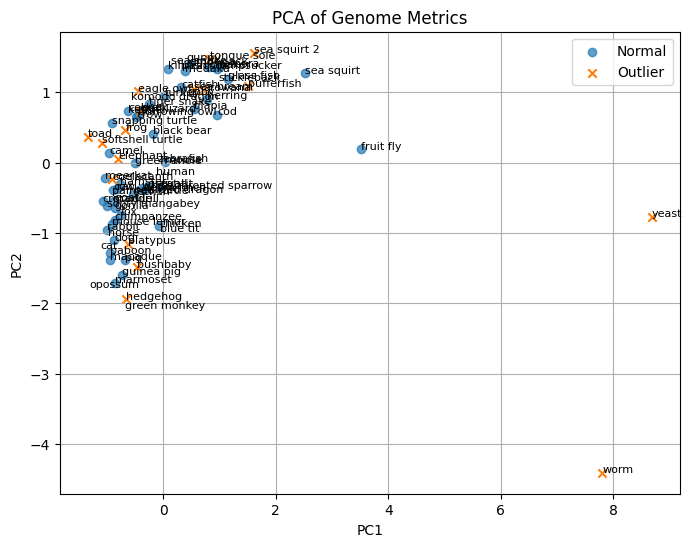

In [ ]:
plot_pca_outliers(final_outliers)

In [ ]:
def plot_boxplot(df, metric):
    plt.figure(figsize=(8,6))

    df.boxplot(column=metric, by='group')

    plt.title(f"{metric} distribution by group")
    plt.suptitle("")
    plt.xlabel("Group")
    plt.ylabel(metric)

    plt.show()

<Figure size 800x600 with 0 Axes>

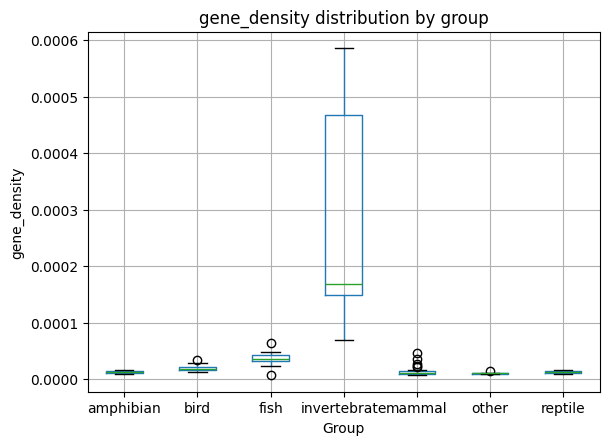

<Figure size 800x600 with 0 Axes>

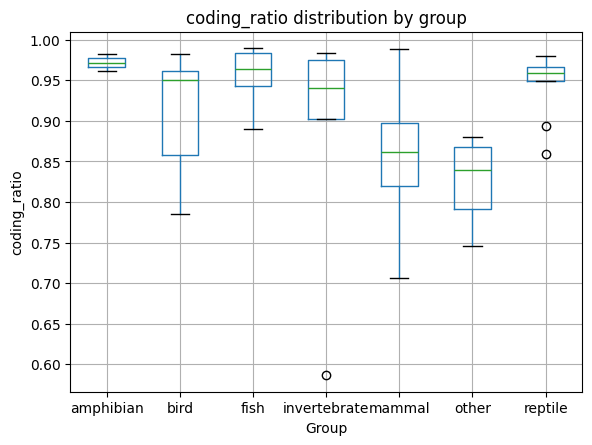

In [ ]:
plot_boxplot(final_outliers, 'gene_density')
plot_boxplot(final_outliers, 'coding_ratio')

In [ ]:
import seaborn as sns

def plot_heatmap(df):
    features = ['coding_ratio','gene_density','avg_gene_length','transcript_density']

    data = df.set_index('species')[features]

    plt.figure(figsize=(10,6))
    sns.heatmap(data, annot=True, fmt=".2f")

    plt.title("Genome Metrics Heatmap")
    plt.show()

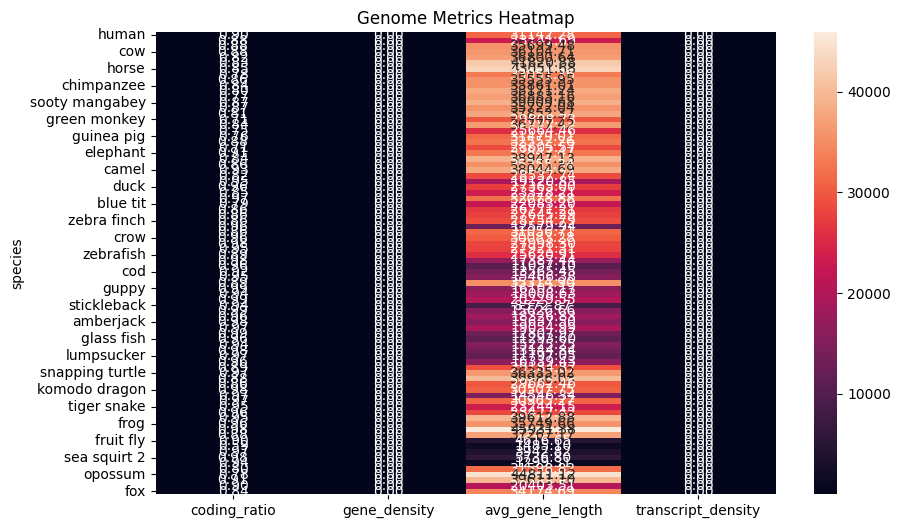

In [ ]:
plot_heatmap(final_outliers)

In [ ]:
def plot_pca_single(df, species):
    plt.figure(figsize=(8,6))

    normal = df[df['final_outlier'] == 'NORMAL']
    outliers = df[df['final_outlier'] == 'OUTLIER']
    target = df[df['species'] == species]

    plt.scatter(normal['PC1'], normal['PC2'], alpha=0.5, label='Normal')
    plt.scatter(outliers['PC1'], outliers['PC2'], marker='x', label='Outlier')

    # highlight selected species
    plt.scatter(target['PC1'], target['PC2'], s=150, label=species.upper())

    plt.title(f"PCA Position: {species}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.grid()

    plt.show()

In [ ]:
def plot_species_vs_group(df, species, metric):
    row = df[df['species'] == species].iloc[0]
    group = row['group']

    group_df = df[df['group'] == group]

    plt.figure(figsize=(6,5))
    plt.boxplot(group_df[metric], vert=True)

    # plot species point
    plt.scatter(1, row[metric], s=100)

    plt.title(f"{species} vs {group} ({metric})")
    plt.ylabel(metric)

    plt.show()

In [ ]:
def save_pca_plot(df, species):
    plt.figure(figsize=(8,6))

    plt.scatter(df['PC1'], df['PC2'], alpha=0.5)
    target = df[df['species'] == species]
    plt.scatter(target['PC1'], target['PC2'], s=150)

    plt.title(f"PCA: {species}")
    plt.savefig(f"{species}_pca.png")
    plt.close()

In [ ]:
def generate_full_report_with_plots(df, species):
    row = df[df['species'] == species].iloc[0]

    report = []

    report.append(f"Genome: {species.upper()}")
    report.append(f"Status: {row['qc_status']}")
    report.append(f"Score: {row['score']}/6\n")

    # ---- Insights ----
    report.append("Key Insights:")

    if row['coding_ratio'] > 0.85:
        report.append("- High coding efficiency")
    else:
        report.append("- Lower coding efficiency")

    # ---- Flags ----
    if row['qc_flags']:
        report.append("\nWarnings:")
        report.extend([f"- {f}" for f in row['qc_flags']])
    else:
        report.append("\nNo major issues detected")

    # ---- Generate plots ----
    plot_pca_single(df, species)
    plot_species_vs_group(df, species, 'gene_density')
    plot_species_vs_group(df, species, 'coding_ratio')

    return "\n".join(report)

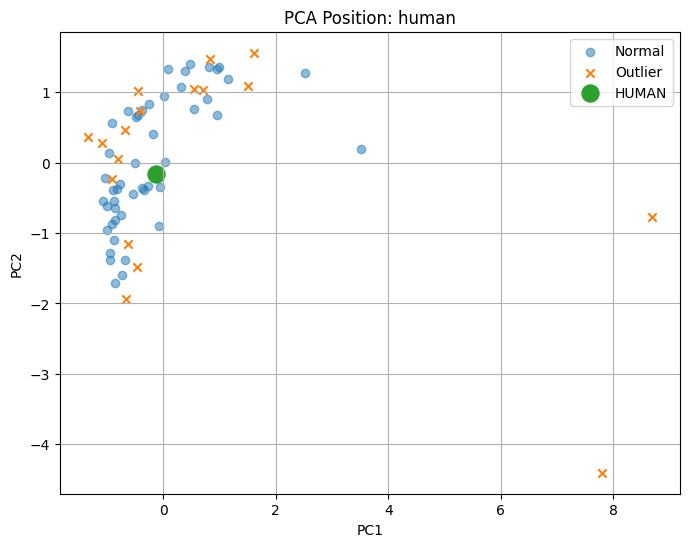

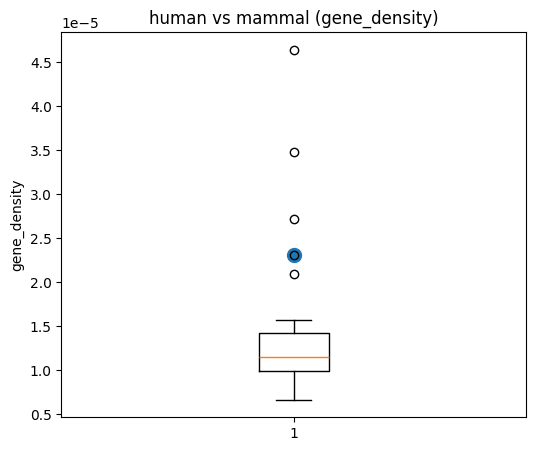

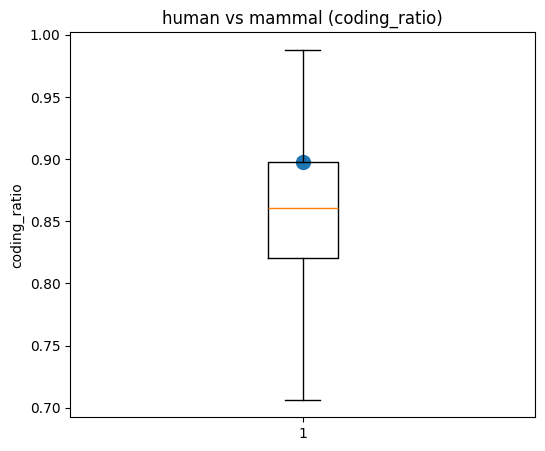

Genome: HUMAN
Status: WARNING
Score: 4/6

Key Insights:
- High coding efficiency

Warnings:
- Z
- ,
- Q


In [ ]:
print(generate_full_report_with_plots(final_outliers, 'human'))